<a href="https://colab.research.google.com/github/Lasdina/online-retail-II-end-to-end-analysis/blob/main/End_to_End_B2B_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Data Preparation & Preprocessing

In [2]:
#Load Dataset
df = pd.read_excel('/content/drive/MyDrive/002.BUILD PORTOFOLIO/online_retail_II.xlsx')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
#Data Understanding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df.shape

(541910, 8)

This dataset encompasses all transactions occurring between December 1, 2010, and December 9, 2011, for a UK-based non-store online retailer. The company operates on a B2B (Business-to-Business) model, where the majority of its customers are wholesalers or small-scale retail owners purchasing giftware in bulk for resale

The dataset contains 541910 rows and 8 columns which is:

**Invoice:** A 6-digit unique transaction identifier. Codes starting with 'C' indicate cancellations.

**StockCode:** A unique identifier assigned to each distinct product.

**Description:** The name or category of the product.

**Quantity:** The number of units purchased per transaction.

**InvoiceDate:** The date and time when the transaction was generated.

**Price:** Product price per unit (in Sterling).

**Customer ID:** A 5-digit unique identifier for each client.

**Country:** The name of the country where the customer resides.




# Handling Missing Value

In [5]:
df.isna().sum()/len(df)*100

,0
Invoice,0.000000
StockCode,0.000000
Description,0.268310
Quantity,0.000000
InvoiceDate,0.000000
Price,0.000000
Customer ID,24.926648
Country,0.000000


25% of the CustomerID were missing and 0.2% of the products didn't have any description.

In [6]:
df['Customer ID'].isnull().sum()

np.int64(135080)

In [7]:
# 1. Removing rows where Customer ID is null
missing_customer = df['Customer ID'].isnull().sum()
df.dropna(subset=['Customer ID'], inplace=True)

In [8]:
# 2. Dropping rows with Price <= 0
# Justification: Zero or negative prices typically indicate data entry errors, promotional adjustments, or stock corrections rather than actual sales revenue.
df = df[df['Price'] > 0]

In [9]:
import re

# 1. Converted StockCode to string format and removed leading/trailing whitespaces to ensure consistency
df['StockCode'] = df['StockCode'].astype(str).str.strip()

# 2. Defined a function to identify physical products
def is_physical_product(code):
    # by matching a pattern of 5 initial digits (e.g., 85123 or 85123A).
    pattern = r'^\d{5}'
    if re.match(pattern, code):
        return True
    return False

# 3. 3. Apply Data Masking / Filtering
# Retain only records matching physical product patterns
df_cleaned = df[df['StockCode'].apply(is_physical_product)].copy()

# Verify results: Identify excluded entries
dropped_codes = df[~df['StockCode'].apply(is_physical_product)]['StockCode'].unique()
print(f"Removed StockCodes: {dropped_codes}")

Removed StockCodes: ['POST' 'D' 'C2' 'M' 'BANK CHARGES' 'PADS' 'DOT' 'CRUK']


The decision to remove all null values was based on a comprehensive analysis which concluded that missing data points could not be recovered through inter-column relationships. Furthermore, non-physical product entries were purged to align with the project's primary objective: Customer Segmentation (RFM). Since tracking individual or store-level purchase history is impossible without a valid Customer ID, such records were deemed irrelevant and excluded to maintain the integrity of the analysis

#Handling Duplicated

In [10]:
df_cleaned.duplicated().sum()

np.int64(5220)

In [11]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
df_cleaned.duplicated().sum()

np.int64(0)

In [13]:
df_cleaned.shape

(399656, 8)

5,220 duplicate rows were identified and removed

#Handling cancels

In [14]:
# Create a new column to flag transaction status
df_cleaned['Is_Cancelled'] = df['Invoice'].astype(str).str.startswith('C')
df_cleaned.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Is_Cancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False


In [15]:
# Split DataFrame for future deep-dive analysis
df_normal = df_cleaned[df_cleaned['Is_Cancelled'] == False].copy()
df_cancelled = df_cleaned[df_cleaned['Is_Cancelled'] == True].copy()
df_cleaned.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Is_Cancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False


In [16]:
df_cancelled.shape

(8506, 9)

In [17]:
df_normal.shape

(391150, 9)

In [18]:
# Feature Engineering: Calculating Total Sales per row
df_normal['Total_Amount'] = (df_normal['Quantity'] * df_normal['Price']).round(2)

In [19]:
print(f"Successful: {df_normal.shape[0]} rows")
print(f"Cancelled (C): {df_cancelled.shape[0]} rows")

Successful: 391150 rows
Cancelled (C): 8506 rows


This phase involved splitting successful and cancelled transactions to ensure data integrity, generating a 'Total Amount' column for monetary analysis, and displaying a detailed summary of transaction volumes for both statuses

In [20]:
df_normal.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Is_Cancelled,Total_Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34


In [ ]:
df_normal.to_csv('data_clear.csv')

#Modelling

In [21]:
# 1. Dim_Customer (Tabel Pelanggan)
dim_customer = df_normal[['Customer ID', 'Country']].drop_duplicates(subset=['Customer ID'])

# 2. Dim_Product (Tabel Produk)
# Kita ambil deskripsi terbaru untuk setiap StockCode
dim_product = df_normal[['StockCode', 'Description', 'Price']].drop_duplicates(subset=['StockCode'])
dim_product.rename(columns={'Price': 'Unit_Price'}, inplace=True)

# 3. Fact_Sales (Tabel Fakta Transaksi)
fact_sales = df_normal[['Invoice', 'Customer ID', 'StockCode', 'Quantity', 'Total_Amount', 'InvoiceDate']]

print("Relational Schema Transformation Successful!")

Relational Schema Transformation Successful!


In [ ]:
dim_customer.shape

(4334, 2)

In [ ]:
dim_product.shape

(3659, 3)

In [ ]:
fact_sales.shape

(391150, 6)

Star Schema Implementation: Transforming a single dataset into a Fact Table and Dimension Tables to create an organized data architecture, optimized for advanced visualization processes

#Data Export for Visualization


In [22]:
# Optimize data types for memory efficiency
fact_sales['Customer ID'] = fact_sales['Customer ID'].astype(int)
dim_customer['Customer ID'] = dim_customer['Customer ID'].astype(int)

# Add sep=',' ---
# Export Fact Sales
fact_sales.to_csv('fact_sales_clean.csv', index=False, sep=',', encoding='utf-8')

# Export Dim Customer
dim_customer.to_csv('dim_customer.csv', index=False, sep=',', encoding='utf-8')

# Export Dim Product
dim_product.to_csv('dim_product.csv', index=False, sep=',', encoding='utf-8')

# Export Fact Cancellations (Return)
df_cancelled.to_csv('fact_cancellations.csv', index=False, sep=',', encoding='utf-8')

print("Export complete! Files are ready for download and Tableau integration.")

/tmp/ipykernel_2429/2976904614.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_sales['Customer ID'] = fact_sales['Customer ID'].astype(int)


Export complete! Files are ready for download and Tableau integration.


Exported datasets are prepared for seamless integration and dashboard development within Tableau

#RFM Analysis for Customer Segmentation

**Calculating RFM Metrics**

1.Recency: Number of days since the last order. A lower value indicates higher engagement.

2.Frequency: The total count of unique orders placed by the customer.

3.Monetary: Total expenditure or spend by the customer.

Rationale: Transforming thousands of raw transaction records into concise, individual customer behavior profiles.

In [23]:
# Establishing the reference date (one day after the last transaction date in the dataset)
snapshot_date = fact_sales['InvoiceDate'].max() + pd.Timedelta(days=1)

# Aggregating data by Customer ID
rfm = fact_sales.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'Invoice': 'nunique',                                   # Frequency
    'Total_Amount': 'sum'                                   # Monetary
})

# Rename columns for improved readability
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'Total_Amount': 'Monetary'
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1437.24
12349,19,1,1457.55
12350,310,1,294.40


In [24]:
rfm.shape

(4334, 3)

**Scoring (1-5 Scale)**
We will segment customers into five groups for each metric.

Note: For Recency, a score of 5 is assigned to the lowest number of days, as recent transactions indicate higher engagement.

In [25]:
# Assigning score labels from 1 to 5
r_labels = range(5, 0, -1) # 5 indicates the most recent (low Recency)
f_labels = range(1, 6)      # 5 indicates the highest frequency
m_labels = range(1, 6)      # 5 indicates the highest monetary value

# # Utilizing qcut to partition the data into five equal quintiles
rfm['R'] = pd.qcut(rfm['Recency'], q=5, labels=r_labels)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=f_labels)
rfm['M'] = pd.qcut(rfm['Monetary'], q=5, labels=m_labels)

# Concatenating scores into a unified RFM_Group column
rfm['RFM_Segment'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm

,Recency,Frequency,Monetary,R,F,M,RFM_Segment
Customer ID,,,,,,,
12346,326,1,77183.60,1,1,5,115
12347,2,7,4310.00,5,5,5,555
12348,75,4,1437.24,2,4,4,244
12349,19,1,1457.55,4,1,4,414
12350,310,1,294.40,1,1,2,112
...,...,...,...,...,...,...,...
18280,278,1,180.60,1,2,1,121
18281,181,1,80.82,1,2,1,121
18282,8,2,178.05,5,3,1,531


**Business Segment Classification (Naming):** Numerical scores can be challenging for marketing teams to interpret

In [26]:
def segment_me(df):
    if df['RFM_Segment'] == '555':
        return 'Champions'
    elif df['R'] == '5':
        return 'Recent Customers'
    elif df['F'] == '5':
        return 'Loyal Customers'
    elif df['M'] == '5':
        return 'Big Spenders'
    elif df['R'] == '1':
        return 'At Risk / Lost'
    else:
        return 'Average/Standard'

rfm['Customer_Status'] = rfm.apply(segment_me, axis=1)

# Analyzing the distribution of customer counts per segment
segment_counts = rfm['Customer_Status'].value_counts()
print(segment_counts)

Customer_Status
Average/Standard    3983
Champions            351
Name: count, dtype: int64


In [34]:
# Displaying all attributes for the Champions segment
champions_list = rfm[rfm['Customer_Status'] == 'Champions']
print(champions_list)

             Recency  Frequency  Monetary  R  F  M RFM_Segment Customer_Status
Customer ID                                                                   
12347              2          7   4310.00  5  5  5         555       Champions
12362              3         10   4737.23  5  5  5         555       Champions
12417              3          9   3226.10  5  5  5         555       Champions
12433              1          7  13375.87  5  5  5         555       Champions
12437              2         18   4447.41  5  5  5         555       Champions
...              ...        ...       ... .. .. ..         ...             ...
18230              9          7   2810.20  5  5  5         555       Champions
18241             10         17   2073.09  5  5  5         555       Champions
18245              7          7   2567.06  5  5  5         555       Champions
18272              3          6   3078.58  5  5  5         555       Champions
18283              4         16   2039.58  5  5  5  

In [ ]:
rfm.to_csv('final_rfm_segmentation.csv')

/tmp/ipykernel_2429/3155058217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Customer_Status', palette='viridis',


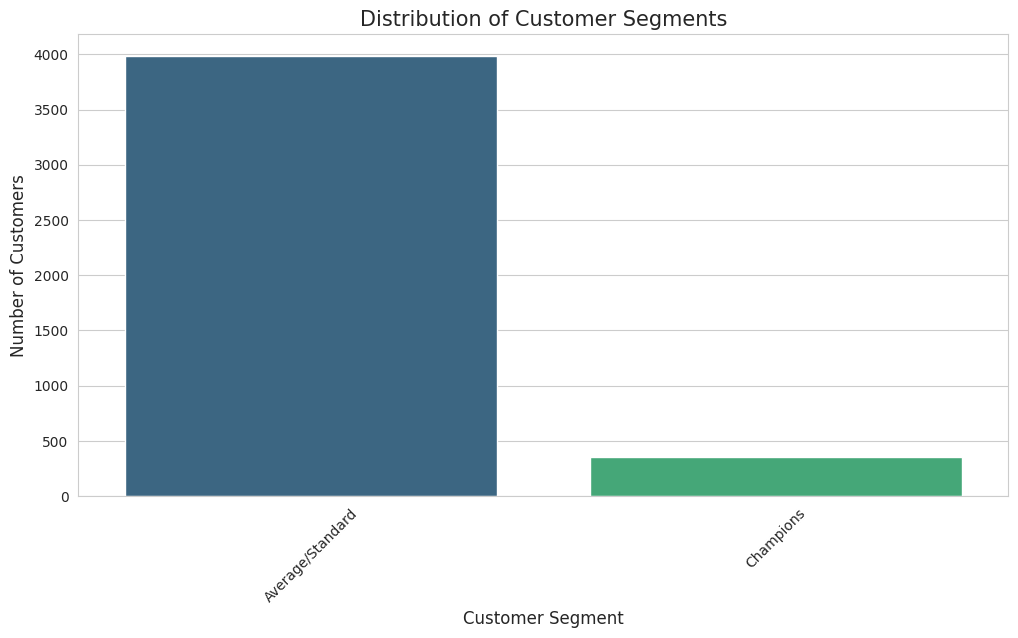

In [27]:
# Configuring visualization aesthetics
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Generating a bar chart based on the Customer_Status column
sns.countplot(data=rfm, x='Customer_Status', palette='viridis',
              order=rfm['Customer_Status'].value_counts().index)

plt.title('Distribution of Customer Segments', fontsize=15)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [28]:
pip install squarify

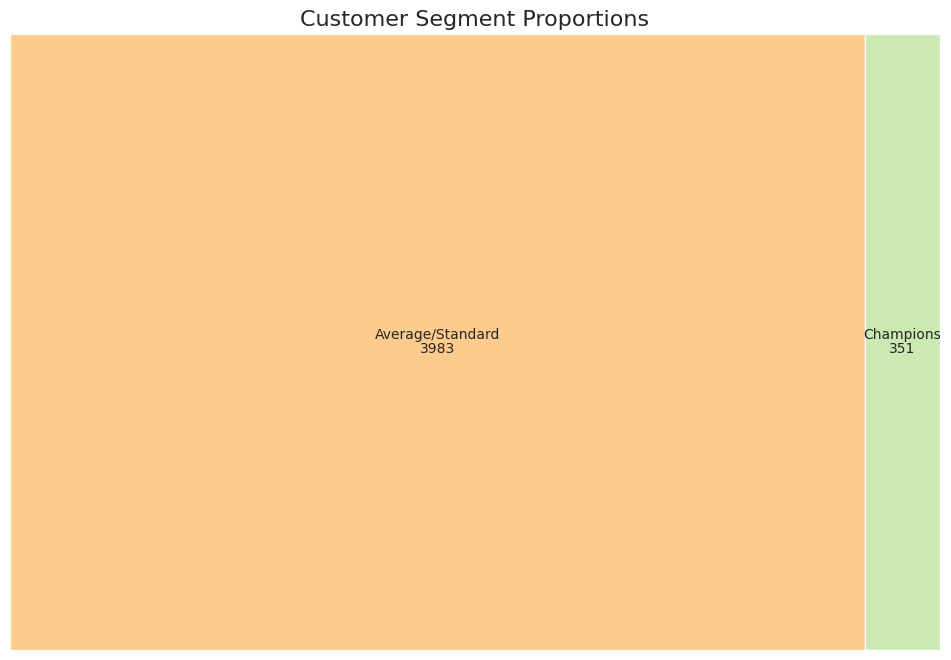

In [29]:
import squarify

# Staging data for Treemap visualization
segment_counts = rfm['Customer_Status'].value_counts().reset_index()
segment_counts.columns = ['Status', 'Count']

plt.figure(figsize=(12, 8))
colors = sns.color_palette('Spectral', len(segment_counts))

squarify.plot(sizes=segment_counts['Count'],
              label=segment_counts['Status'],
              alpha=0.8,
              color=colors,
              value=segment_counts['Count'])

plt.title('Customer Segment Proportions', fontsize=16)
plt.axis('off')
plt.show()

In [33]:
# Average RFM Metrics: Champions Segment
champions_stats = rfm[rfm['Customer_Status'] == 'Champions'].describe()
print(champions_stats)

          Recency   Frequency       Monetary
count  351.000000  351.000000     351.000000
mean     5.527066   18.082621   11032.275527
std      3.659622   20.069351   26321.993611
min      1.000000    6.000000    2031.780000
25%      2.000000    9.000000    3025.960000
50%      4.000000   13.000000    4447.410000
75%      9.000000   20.000000    8245.600000
max     14.000000  206.000000  279138.020000


/tmp/ipykernel_2429/718428108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Customer_Status', y='Monetary', data=rfm, palette='coolwarm')


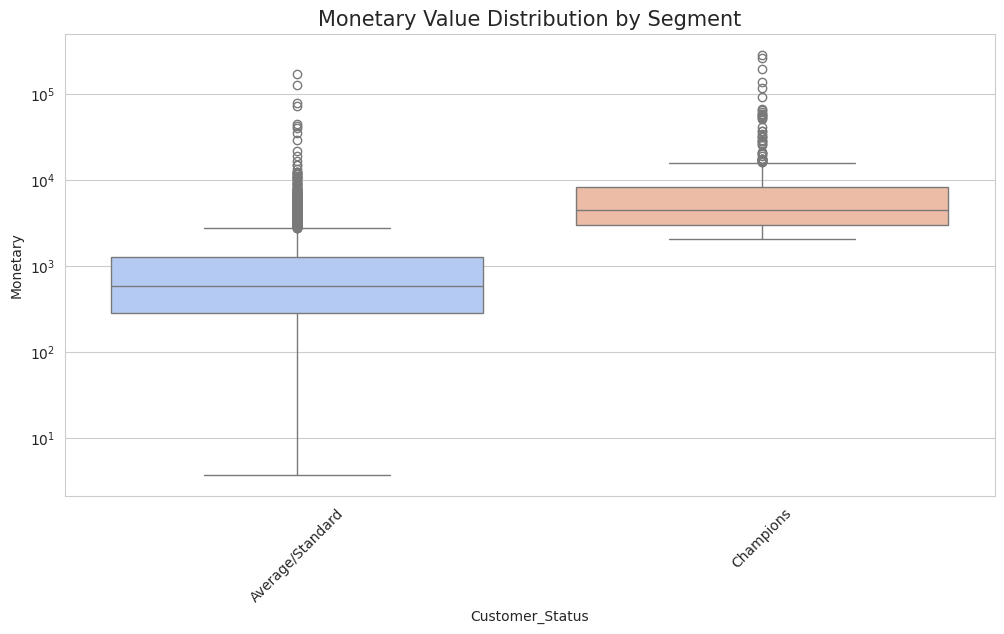

In [30]:
# Analyzing Monetary value distribution (spending) across segments
plt.figure(figsize=(12, 6))
sns.boxplot(x='Customer_Status', y='Monetary', data=rfm, palette='coolwarm')

plt.title('Monetary Value Distribution by Segment', fontsize=15)
plt.yscale('log') # Applying a logarithmic scale to handle extreme outliers (e.g., Customer ID 12346)
plt.xticks(rotation=45)
plt.show()

The Champions segment exhibits a significantly higher median monetary value compared to the Average/Standard segment. Furthermore, the presence of numerous outliers across both segments—particularly those reaching the 10^5 spending scale—indicates the existence of individual customers with exceptional transaction values that far exceed the average

#Exploratory Data Analysis
Monthly Sales Trend Analysis (EDA): Assessing seasonal fluctuations in distributor performance

/tmp/ipykernel_2429/1466057987.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_sales['Month_Year'] = fact_sales['InvoiceDate'].dt.to_period('M')


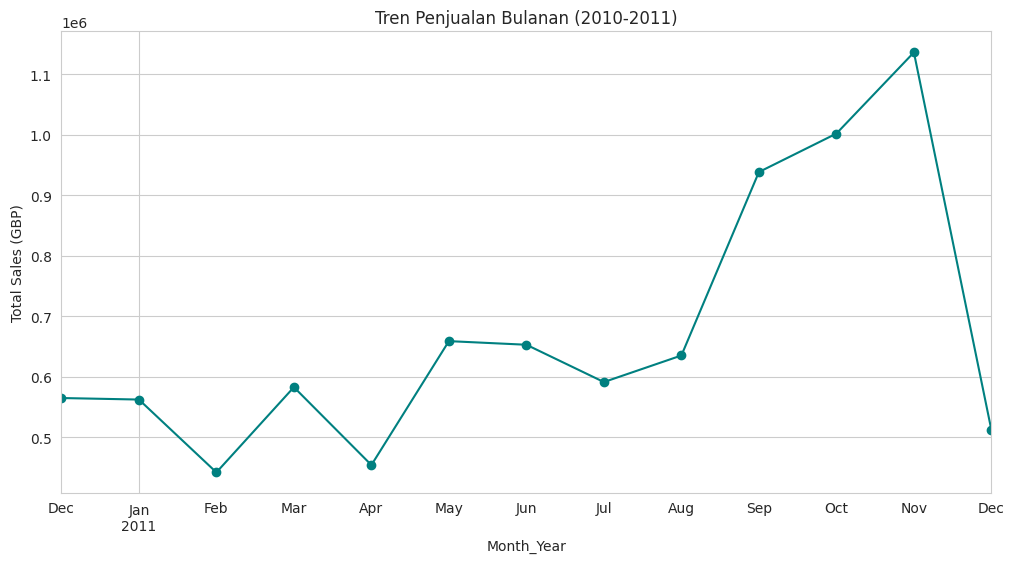

In [35]:
# Adding a Month-Year column for trend analysis
fact_sales['Month_Year'] = fact_sales['InvoiceDate'].dt.to_period('M')
monthly_sales = fact_sales.groupby('Month_Year')['Total_Amount'].sum()

# Visualization
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line', marker='o', color='teal')
plt.title('Tren Penjualan Bulanan (2010-2011)')
plt.ylabel('Total Sales (GBP)')
plt.grid(True)
plt.show()

November marked the peak sales period, fueled by holiday-related stock preparation. Future action plans include scaling up inventory reserves during September and October to meet the anticipated high-volume demand